In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print ("hi")

hi


In [6]:


class TrajectoryValidationRiskPloter:
    def __init__(self, test_samples = 1e5, random_seed = 42):
        self.X = None
        self.y = None

        self.train_X = None
        self.train_y = None
        self.test_X = None
        self.test_y = None

        self.test_X = None
        self.test_y = None

        self.w_traj = None
        self.train_over_time = None
        self.valid_over_time = None
        self.test_over_time = None

        self.beta_0 = None
        self.noise_sigma = None

        self.isotropic = True
        self.rng = np.random.default_rng(random_seed)

        # self.p = p
        # self.max_T = max_T

    # def set_max_T (self, T):
    #     self.max_T = T

    def split_train_valid(self, ratio=0.5):
            n = len(self.X)
            training_size = int (n * ratio)
            X_train = self.X[0:training_size,:]
            y_train = self.y[0:training_size]

            X_valid = self.X[training_size:,:]
            y_valid = self.y[training_size:]

            return X_train, y_train, X_valid, y_valid


    def generate_data(self, n = 3000, p = 6000, paper = "patil24a", 
                      isotropic = True, 
                      Sigma = None, 
                      beta_0 = None, noise_sigma = 1):

        # p += 1 # In the paper there is +1 for dimension, we ignore that for now. 
        # # I don't know if there is any implication: TODO: check


        # m is the number of validation samples
        # n is the number of training samples
        # p is dimension
        

        if beta_0 is None:
            beta_0 = 5 * np.identity(p)[0]
        self.beta_0 = beta_0
        
        if isotropic:
            self.isotropic = True
            Sigma = np.identity(p)
        else:
            if Sigma is None:
                raise ValueError("Sigma is not specified")
            
        self.Sigma = Sigma

        # generate training samples
        if isotropic:
            X = self.rng.standard_normal(size=(n, p))
        else:
            X = self.rng.multivariate_normal(mean=np.zeros(p), cov=Sigma, size=n)
        
        y = X @ beta_0 + self.rng.normal(0, noise_sigma, n)

        # # generate valid samples
        # if isotropic:
        #     X_valid = self.rng.standard_normal(size=(m, p))
        # else:
        #     X_valid = self.rng.multivariate_normal(mean = np.zeros(p), cov = Sigma, size = m)
        
        # y_valid = X_valid @ beta_0 + self.rng.normal(0, noise_sigma, m)


        return X, y

    # def test_risk_using_fresh_samples(
    #         self, w, p, beta_0, noise_sigma, fresh_test_sample_size, Sigma = None
    #         ):
    #     if self.test_X is None:
    #         if self.isotropic is True:
    #             self.test_X = self.rng.standard_normal(size=(fresh_test_sample_size, p))
    #         else:
    #             self.test_X = self.rng.multivariate_normal(mean = np.zeros(p),
    #                                       cov = Sigma, size=fresh_test_sample_size)
    #         self.test_y = self.test_X @ beta_0 + self.rng.normal(
    #             0, noise_sigma, fresh_test_sample_size
    #             )
    #     # ok now data is generated, let's measure test error:
    #     return self.evaluate(w, self.test_X,self.y)
        

    def run_LOOCV(
            self, X_train, y_train, eta=0.1, w_0 = None, max_T = 5e2,
            test_error_tracking = False, 
            X_test = None,
            y_test = None
            ):
        # for each training data, create X_train, y_train without that sample, 
        # run GD, have validation set with that one sample 

        max_T = int(max_T)
        LOOCV_error = np.zeros(max_T)
        test_error_aggregate = None
        if test_error_tracking:
            test_error_aggregate = np.zeros(max_T)
        for i in range(0, len(X_train)):
            # prep the data
            X_train_leave_one_out = np.delete(X_train, i, axis=0)
            y_train_leave_one_out = np.delete(y_train, i, axis=0)
            X_left_one = X_train[i].reshape(1,-1)
            y_left_one = y_train[i:i+1]

            _, _, current_LOOCV_error, test_error = self.run_GD_efficient(
                                X_train_leave_one_out, y_train_leave_one_out, X_left_one,
                                y_left_one, X_test, y_test, 
                                train_error_tracking = False,
                                valid_error_tracking = True,
                                test_error_tracking = test_error_tracking,
                                eta = eta,
                                max_T = max_T)
            LOOCV_error += current_LOOCV_error

            if test_error_tracking:
                test_error_aggregate += test_error


        LOOCV_error /= len(X_train)

        if test_error_tracking:
            test_error_aggregate/= len(X_train) # we have these many runs of GD

        return LOOCV_error, test_error_aggregate
    

    def run_GD_efficient(
            self, X_train, y_train, X_valid, y_valid, X_test, y_test, eta=0.1, w_0 = None, 
            max_T = 5000,
            train_error_tracking= True,
            valid_error_tracking = True, 
            test_error_tracking = True
            ):

        # running the GD -------------------
        if (w_0 is None):
            w_0 = np.zeros(len(X_train[0]))
        n = len(X_train)

        
        training_error_over_time = []
        validation_error_over_time = []
        test_error_over_time = []

        w_prev = w_0
        w_t = w_prev
        for t in range(0, int(max_T)):

            # record the errors
            if train_error_tracking:
                training_error_over_time.append(self.evaluate(w_t, X_train, y_train))
            if valid_error_tracking:
                validation_error_over_time.append(self.evaluate(w_t, X_valid, y_valid))
            if test_error_tracking:
                test_error_over_time.append(self.evaluate(w_t, X_test, y_test))

            # grad step
            w_t = w_prev + (eta/n) * X_train.T @ (y_train - X_train @ w_prev)
            w_prev = w_t

        return None, training_error_over_time, validation_error_over_time, test_error_over_time
    

  


    def evaluate(self, w, X, y):
        n = len(X)
        r = y - X @ w
        return np.dot(r,r) / ( n) 
        

    def run_hold_out_GD(self, n = 3000 , p = 6000, m=2000, test_sample_size =1e4, 
                        test_error_tracking=False, eta = 0.1, max_T = 1e5
                        ):
        

        X_train, y_train = self.generate_data(n=n, p=p)
        X_valid, y_valid = self.generate_data(n=m, p=p)

        X_test , y_test = None, None
        if test_error_tracking:
            X_test, y_test = self.generate_data(n=test_sample_size, p=p)

        _ , train_over_time, valid_over_time, test_over_time = self.run_GD_efficient(
            X_train, y_train, X_valid, y_valid, X_test, y_test, 
            test_error_tracking = test_error_tracking,
            eta = eta, max_T=max_T
        )
        return train_over_time, valid_over_time, test_over_time

    def generate_samples_and_run_LOOCV(
            self, n = 3000 , p = 6000, test_sample_size =1e4, test_error_tracking=False, 
            eta=0.1, max_T = 1e5
            ):
        

        X_train, y_train = self.generate_data(n=n, p=p)
        
        X_test , y_test = None, None
        if test_error_tracking:
            X_test, y_test = self.generate_data(n=test_sample_size, p=p)

        LOOCV_error, test_error_aggregate = self.run_LOOCV(
            X_train, y_train, eta=eta, w_0 = None, max_T = max_T,
            test_error_tracking = test_error_tracking, 
            X_test = X_test,
            y_test = y_test
            )
        

        return LOOCV_error, test_error_aggregate



    ### warning the following is LLM GENERATED
    def run_GCV(self, X_train, y_train, eta=0.1, max_T=5000,
            test_error_tracking=False, X_test=None, y_test=None):

        n, p = X_train.shape
        max_T = int(max_T)

        # Precompute eigenvalues of gram matrix — use smaller of XX^T/n or X^TX/n
        if n <= p:
            gram = X_train @ X_train.T / n  # n×n
        else:
            gram = X_train.T @ X_train / n  # p×p
        eigvals = np.linalg.eigvalsh(gram)
        eigvals = eigvals[eigvals > 1e-10]  # drop numerical zeros

        w = np.zeros(p)
        gcv_over_time = []
        test_error_over_time = [] if test_error_tracking else None

        for k in range(max_T):
            # tr[H_k] = sum_j [1 - (1 - eta * lambda_j)^k]
            trace_Hk = np.sum(1 - (1 - eta * eigvals) ** k)
            dof_correction = (1 - trace_Hk / n) ** 2

            gcv_over_time.append(self.evaluate(w, X_train, y_train) / dof_correction)

            if test_error_tracking:
                test_error_over_time.append(self.evaluate(w, X_test, y_test))

            # gradient step
            w = w + (eta / n) * X_train.T @ (y_train - X_train @ w)

        return gcv_over_time, test_error_over_time


    def generate_samples_and_run_GCV(self, n=3000, p=6000, test_sample_size=1e4,
                                    test_error_tracking=False, eta=0.1, max_T=1e5):
            X_train, y_train = self.generate_data(n=n, p=p)

            X_test, y_test = None, None
            if test_error_tracking:
                X_test, y_test = self.generate_data(n=int(test_sample_size), p=p)

            return self.run_GCV(X_train, y_train, eta=eta, max_T=max_T,
                                test_error_tracking=test_error_tracking,
                                X_test=X_test, y_test=y_test)


    def plot_trajectories(self, arrays: dict, title: str = "Risk over GD Iterations"): 
        # note: this function is LLM generated
        """
        arrays: dict mapping label -> 1D array, e.g.
            {"Train": train_over_time, "Valid": valid_over_time, "LOOCV": loocv_error}
        """

        fig, ax = plt.subplots(figsize=(8, 5))

        for label, arr in arrays.items():
            if arr is not None:
                ax.plot(range(1, len(arr) + 1), arr, label=label)

        ax.set_xlabel("Iteration $t$")
        ax.set_ylabel("MSE")
        ax.set_title(title)
        ax.legend()
        plt.tight_layout()
        plt.show()



Now we instantiate the class: 

In [4]:
print('test')

test


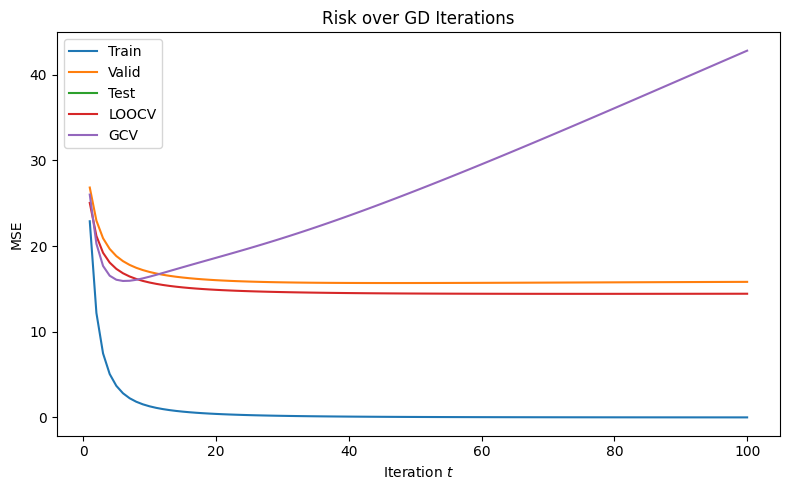

In [7]:
plotter = TrajectoryValidationRiskPloter()

max_T = 100
train_over_time, valid_over_time, test_over_time = plotter.run_hold_out_GD(n=300, p=600, max_T=max_T)
loocv_error, _ = plotter.generate_samples_and_run_LOOCV(n=300, p=600, max_T=max_T)
gcv_error, _ = plotter.generate_samples_and_run_GCV(n=300, p=600, max_T=max_T)

plotter.plot_trajectories({
    "Train": train_over_time,
    "Valid": valid_over_time,
    "Test": test_over_time,
    "LOOCV": loocv_error,
    "GCV": gcv_error
})

In [50]:
print("hey")

hey


In [5]:
# a = np.zeros((3,4))
# print(len(a))
# print(len(a[0]))

a = np.arange(48).reshape(16,3)
print (a)
print ('---')
print (np.delete(a, 2, axis=0))


[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]
 [24 25 26]
 [27 28 29]
 [30 31 32]
 [33 34 35]
 [36 37 38]
 [39 40 41]
 [42 43 44]
 [45 46 47]]
---
[[ 0  1  2]
 [ 3  4  5]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]
 [21 22 23]
 [24 25 26]
 [27 28 29]
 [30 31 32]
 [33 34 35]
 [36 37 38]
 [39 40 41]
 [42 43 44]
 [45 46 47]]
